Generated 359 valid assignment pairs based on Granular Skills & Seniority.

✅ Status: OPTIMAL (MILP Solution)
💰 Total Optimized Cost: $1,758,009.00

--- Snippet of Optimal Assignment Schedule ---


,Task_ID,Employee_ID,Bottleneck_Rho,Clock_Hours,Cost,Req_Dict,Skills_Dict
0,P001_T1,E077,0.5,1400.0,57400.0,{'JUnit': 2},{'JUnit': 1}
1,P001_T2,E044,1.0,600.0,49800.0,"{'C#': 3, 'Node.js': 1}","{'C#': 3, 'Node.js': 1}"
2,P002_T1,E069,1.5,532.0,68096.0,"{'Tableau': 1, 'Pandas': 1}","{'SQL': 1, 'Tableau': 2, 'Pandas': 2, 'Docker'..."
3,P002_T1,E096,1.0,2.0,224.0,"{'Tableau': 1, 'Pandas': 1}","{'Pandas': 3, 'Tableau': 1, 'SQL': 2}"
4,P002_T2,E027,1.0,200.0,7600.0,{'Node.js': 1},{'Node.js': 1}
5,P002_T3,E025,0.5,800.0,60000.0,"{'Angular': 3, 'TypeScript': 3}","{'TypeScript': 1, 'React': 1, 'Angular': 1}"
6,P003_T1,E052,1.0,300.0,30000.0,"{'React': 3, 'TypeScript': 1}","{'TypeScript': 2, 'React': 3}"
7,P003_T2,E001,1.5,133.0,15694.0,{'Go': 2},"{'Go': 3, 'PyTest': 3}"
8,P003_T2,E057,0.5,1.0,65.0,{'Go': 2},"{'C#': 1, 'Go': 1, 'Cypress': 1}"
9,P003_T3,E091,1.5,534.0,43254.0,{'SQL': 1},"{'SQL': 2, 'Tableau': 1, 'Spark': 1}"



📊 Saved Chart 1 (False Economy) to: 2026-04-19_21-23-31/false_economy_chart.png


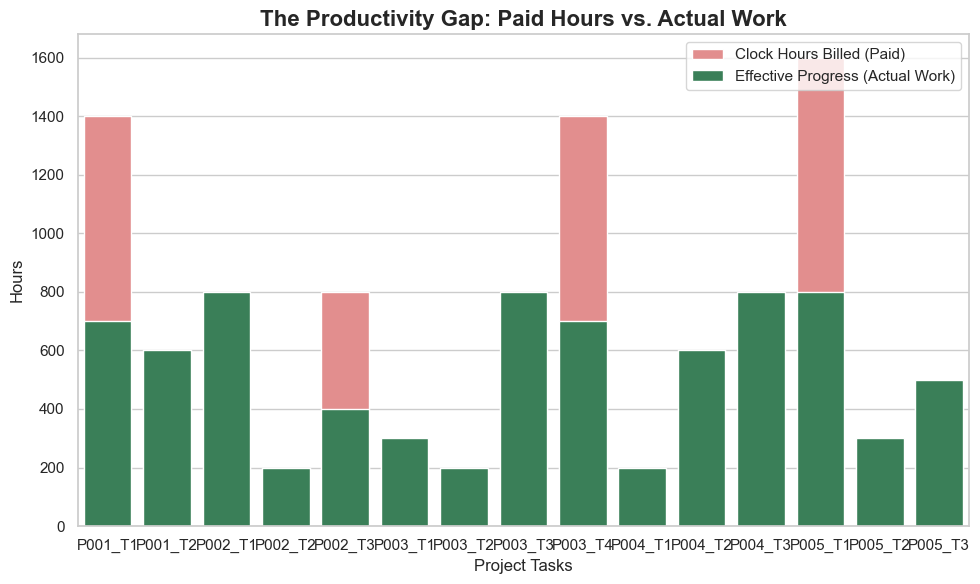

📊 Saved Chart 2 (Cost Distribution) to: 2026-04-19_21-23-31/cost_distribution_chart.png


/var/folders/rv/jrnyg0dj6610p3b7wcp05hg40000gn/T/ipykernel_16640/1912372370.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=cost_summary[:15], x='Employee_ID', y='Cost', palette='viridis')


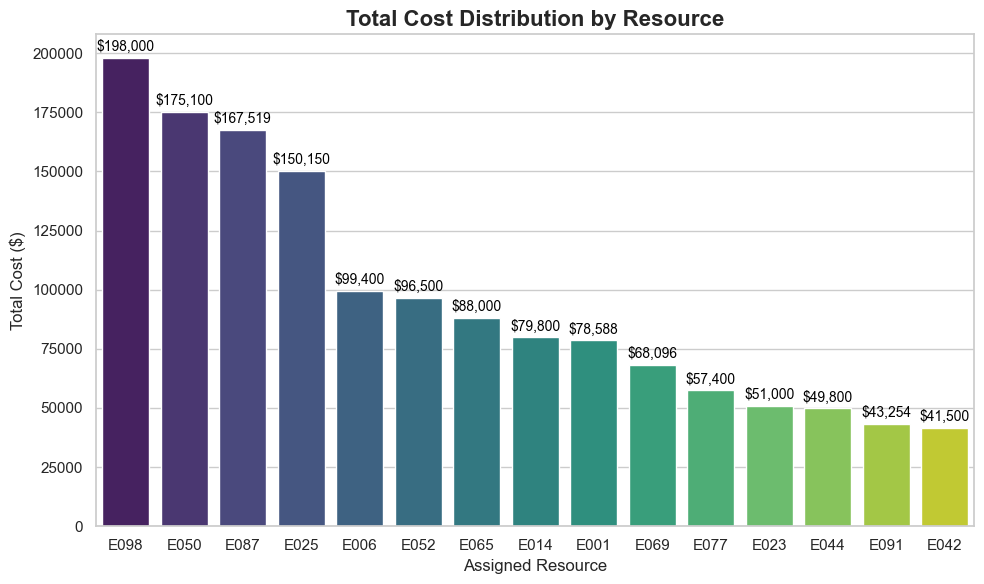

In [13]:
import pandas as pd
import json
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD AND PREP DATA
# ==========================================
# UPDATE THIS PATH to the folder generated by Script 1
EXPORT_PATH = '2026-04-19_21-23-31' 

try:
    employees_df = pd.read_csv(f'{EXPORT_PATH}/employees.csv')
    tasks_df = pd.read_csv(f'{EXPORT_PATH}/tasks.csv')
except FileNotFoundError:
    print("Error: Could not find the CSVs.")
    raise

# Parse JSON strings back into native Python dictionaries
employees_df['Skills_Dict'] = employees_df['Skills_Dict'].apply(json.loads)
tasks_df['Req_Dict'] = tasks_df['Req_Dict'].apply(json.loads)

# Build the EXT_CONTRACTOR (Possesses Level 3 in EVERY required skill)
all_required_skills = set()
for req_dict in tasks_df['Req_Dict']:
    all_required_skills.update(req_dict.keys())

contractor_skills = {skill: 3 for skill in all_required_skills}

contractor = pd.DataFrame([{
    'Employee_ID': 'EXT_CONTRACTOR',
    'Skills_Dict': contractor_skills,
    'Hourly_Cost': 5000,
    'Max_Hours': 999999
}])
employees_df = pd.concat([employees_df, contractor], ignore_index=True)


# ==========================================
# 2. VALID PAIRS & THE BOTTLENECK PRINCIPLE
# ==========================================
def calculate_skill_rho(emp_level, task_level):
    if emp_level == task_level:
        return 1.0
    elif emp_level > task_level:
        return 1.5
    else:
        return 0.5

valid_pairs = []
rho_dict = {} 

for _, emp in employees_df.iterrows():
    emp_skills = emp['Skills_Dict']
    
    for _, task in tasks_df.iterrows():
        task_reqs = task['Req_Dict']
        
        # 1. Conjunctive Check: Does employee have all required specific skills?
        if set(task_reqs.keys()).issubset(set(emp_skills.keys())):
            
            # 2. Calculate rho for each required skill
            skill_rhos = []
            for skill, req_level in task_reqs.items():
                emp_level = emp_skills[skill]
                skill_rhos.append(calculate_skill_rho(emp_level, req_level))
            
            # 3. Apply the Bottleneck Principle
            overall_rho = min(skill_rhos)
            
            pair = (emp['Employee_ID'], task['Task_ID'])
            valid_pairs.append(pair)
            rho_dict[pair] = overall_rho

print(f"Generated {len(valid_pairs)} valid assignment pairs based on Granular Skills & Seniority.")


# ==========================================
# 3. BUILD THE MILP SOLVER (SCIP)
# ==========================================
solver = pywraplp.Solver.CreateSolver('SCIP')

# A. Decision Variables (Integer)
x = {}
for (i, j) in valid_pairs:
    x[(i, j)] = solver.IntVar(0, solver.infinity(), f'x_{i}_{j}')

# B. Objective Function (Minimize Cost)
cost_dict = employees_df.set_index('Employee_ID')['Hourly_Cost'].to_dict()
objective = solver.Objective()
for (i, j) in valid_pairs:
    objective.SetCoefficient(x[(i, j)], float(cost_dict[i]))
objective.SetMinimization()

# C. Constraint 1: Demand Satisfaction (With Bottleneck Rho)
demand_dict = tasks_df.set_index('Task_ID')['Hours_Needed'].to_dict()
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    constraint = solver.Constraint(float(demand_dict[j]), solver.infinity(), f"Demand_{j}")
    for i in capable_employees:
        # Fetch the pre-calculated bottleneck rho
        rho = rho_dict[(i, j)]
        constraint.SetCoefficient(x[(i, j)], float(rho))

# D. Constraint 2: Integer Capacity Limit
cap_dict = employees_df.set_index('Employee_ID')['Max_Hours'].to_dict()
for i in employees_df['Employee_ID']:
    assigned_tasks = [j for (e_id, j) in valid_pairs if e_id == i]
    constraint = solver.Constraint(0, float(cap_dict[i]), f"Capacity_{i}")
    for j in assigned_tasks:
        constraint.SetCoefficient(x[(i, j)], 1)


# ==========================================
# 4. SOLVE & EXTRACT
# ==========================================
status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print(f"\n✅ Status: OPTIMAL (MILP Solution)")
    print(f"💰 Total Optimized Cost: ${solver.Objective().Value():,.2f}")
    
    results = []
    for (i, j) in valid_pairs:
        assigned_clock_hours = x[(i, j)].solution_value()
        if assigned_clock_hours > 0: 
            rho = rho_dict[(i, j)]
            results.append({
                'Task_ID': j,
                'Employee_ID': i,
                'Bottleneck_Rho': rho,
                'Clock_Hours': assigned_clock_hours,
                'Effective_Progress': assigned_clock_hours * rho,
                'Cost': assigned_clock_hours * cost_dict[i]
            })
            
    results_df = pd.DataFrame(results).sort_values(by=['Task_ID', 'Employee_ID']).reset_index(drop=True)
    
    # Merge for display clarity
    display_df = results_df.merge(tasks_df[['Task_ID', 'Req_Dict']], on='Task_ID')
    display_df = display_df.merge(employees_df[['Employee_ID', 'Skills_Dict']], on='Employee_ID')
    
    print("\n--- Snippet of Optimal Assignment Schedule ---")
    display(display_df[['Task_ID', 'Employee_ID', 'Bottleneck_Rho', 'Clock_Hours', 'Cost', 'Req_Dict', 'Skills_Dict']].head(30))
    
    # Contractor check
    contractor_hrs = results_df[results_df['Employee_ID'] == 'EXT_CONTRACTOR']['Clock_Hours'].sum()
    if contractor_hrs > 0:
        print(f"\n🚨 ALERT: Outsourced {contractor_hrs:,.0f} hours to EXT_CONTRACTOR due to skill/capacity shortages.")
else:
    print("Solver failed. Status:", status)

# ==========================================
# 5. VISUALIZING THE RESULTS FOR PRESENTATION
# ==========================================

# Set a clean, professional style
sns.set_theme(style="whitegrid")

# --- CHART 1: The "False Economy" (Clock vs. Effective Hours) ---
# We will group by Task to see how inefficient some assignments were
task_summary = display_df.groupby('Task_ID')[['Clock_Hours', 'Effective_Progress']].sum().reset_index()

plt.figure(figsize=(10, 6))
# Plot Clock Hours (The larger background bar)
sns.barplot(data=task_summary[:15], x='Task_ID', y='Clock_Hours', color='lightcoral', label='Clock Hours Billed (Paid)')
# Plot Effective Progress (The smaller foreground bar)
sns.barplot(data=task_summary[:15], x='Task_ID', y='Effective_Progress', color='seagreen', label='Effective Progress (Actual Work)')

plt.title('The Productivity Gap: Paid Hours vs. Actual Work', fontsize=16, fontweight='bold')
plt.xlabel('Project Tasks', fontsize=12)
plt.ylabel('Hours', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()

# Save it to your folder for Canva!
chart1_path = f"{EXPORT_PATH}/false_economy_chart.png"
plt.savefig(chart1_path, dpi=300)
print(f"\n📊 Saved Chart 1 (False Economy) to: {chart1_path}")
plt.show()


# --- CHART 2: Portfolio Cost Breakdown ---
# Shows how much of the budget went to internal staff vs the expensive contractor
cost_summary = display_df.groupby('Employee_ID')['Cost'].sum().reset_index()
cost_summary = cost_summary.sort_values('Cost', ascending=False)

plt.figure(figsize=(10, 6))
bars = sns.barplot(data=cost_summary[:15], x='Employee_ID', y='Cost', palette='viridis')

# Highlight the Contractor in red if they were used
for i, bar in enumerate(bars.patches):
    if cost_summary.iloc[i]['Employee_ID'] == 'EXT_CONTRACTOR':
        bar.set_color('firebrick')

plt.title('Total Cost Distribution by Resource', fontsize=16, fontweight='bold')
plt.xlabel('Assigned Resource', fontsize=12)
plt.ylabel('Total Cost ($)', fontsize=12)

# Add dollar values on top of the bars
for p in bars.patches:
    bars.annotate(f'${p.get_height():,.0f}', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), 
                  textcoords='offset points')

plt.tight_layout()

chart2_path = f"{EXPORT_PATH}/cost_distribution_chart.png"
plt.savefig(chart2_path, dpi=300)
print(f"📊 Saved Chart 2 (Cost Distribution) to: {chart2_path}")
plt.show()